# 손실함수의 선택 

## A. 손실함수 선택 룰 

`-` 아래의 도표로 충분할까?

|$y$|분포가정|마지막층의 활성화함수|손실함수|
|:--:|:--:|:--:|:--:|
|3.45, 4.43, ... (연속형) |정규분포|None (or Identity)|MSE|
|0 or 1|이항분포 with $n=1$ (=베르누이) |Sigmoid| BCE|
|[0,0,1], [0,1,0], [1,0,0]| 다항분포 with $n=1$|Softmax| Cross Entropy |

## B. 로버스트 회귀

`-` 아래의 모형을 가정하고 시뮬레이션으로 데이터를 얻자. (박혜원모드X, 신모드O)

$$\quad y_i = 2 x_i + 1 + \epsilon_i,\quad \epsilon_i \sim \text{Laplace}(0,\,b)$$

`-` 데이터 생성

In [ ]:
torch.manual_seed(17)
x = torch.linspace(-2, 2,100).reshape(-1, 1)
eps = torch.distributions.Laplace(0.0,2).sample((100, 1))
y = 2*x + 1 + eps

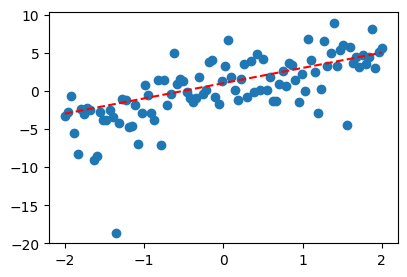

In [ ]:
plt.plot(x, y, 'o')
plt.plot(x, 2*x + 1, '--r')

`-` MSE로 학습 (일반 회귀)

In [ ]:
torch.manual_seed(1)
net_mse = torch.nn.Sequential(
    torch.nn.Linear(1,1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net_mse.parameters(),lr=0.1)
#---#
for epoc in range(1000):
    ## step1
    yhat = net_mse(x)
    ## step2
    loss = loss_fn(yhat,y)
    ## step3
    loss.backward()
    ## step4
    optimizr.step()
    optimizr.zero_grad()

`-` MAE로 학습 (로버스트 회귀)

In [ ]:
torch.manual_seed(1)
net_mae = torch.nn.Sequential(
    torch.nn.Linear(1,1)
)
loss_fn = torch.nn.L1Loss()
optimizr = torch.optim.Adam(net_mae.parameters(),lr=0.1)
#---#
for epoc in range(1000):
    ## step1
    yhat = net_mae(x)
    ## step2
    loss = loss_fn(yhat,y)
    ## step3
    loss.backward()
    ## step4
    optimizr.step()
    optimizr.zero_grad()

`-` 결과 비교

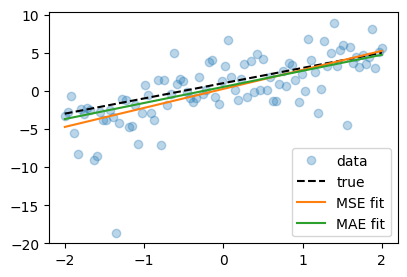

In [ ]:
plt.plot(x, y, 'o', alpha=0.3, label='data')
plt.plot(x, 2*x + 1, '--', color='k', label='true')
plt.plot(x, net_mse(x).data, '-', color='C1', label='MSE fit')
plt.plot(x, net_mae(x).data, '-', color='C2', label='MAE fit')
plt.legend()

`-` 일반적으로 이러한 상황에서는 MAE가 더 좋다고 알려져있다. 

`-` 따라서 표를 업데이트하면 아래와 같이 할 수 있겠다

|$y$|분포가정|마지막층의 활성화함수|손실함수|
|:--:|:--:|:--:|:--:|
|3.45, 4.43, ... (연속형) |정규분포|None (or Identity)|MSE|
|0 or 1|이항분포 $B(1,p)$ (=베르누이) |Sigmoid| BCE|
|[0,0,1], [0,1,0], [1,0,0]| 다항분포 $M(1,{\bf p})$ |Softmax| Cross Entropy |
|3.45, 4.43, ... (연속형) |라플라스분포|None (or Identity)|MAE|

## C. 정리

`-` 이를 특별히 로버스트회귀라고 부름.

`-` 잘 살펴보면 net의 아키텍처는 동일하다. 다른점이 있다면 오차항차이. $\Rightarrow$ 통계학과에서 모델링은 net의 아키텍처뿐 아니라 오차항의 분포까지 모두 고려하는 보다 섬세한 개념임. 

`-` 그렇다면 손실함수는 어떻게?? 보통 "손실함수는 음의로그가능도(Negative Log Likelihood, NLL)로 잡으세요" 라고 가르치는게 안전하다. 

- 회귀: -로그가능도(NLL)를 계산하면 MSELoss와 식이 같아진다.
- 로지스틱: -로그가능도(NLL)를 계산하면 BCELoss와 식이 같아진다.
- 로버스트회귀: -로그가능도(NLL)를 계산하면 L1Loss와 식이 같아진다. 

`-` 그런데 꼭 손실함수를 NLL로 잡지 않는 경우도 있다. (살짝 깊은 이야기)

`-` 실무적으로는 대~~~~~충 아래와 같이 잡으면된다. 

|$y$|마지막층의 활성화함수|손실함수|
|:--:|:--:|:--:|
|3.45, 4.43, ...|None (or Identity)|MSE|
|0 or 1|Sigmoid| BCE|
|[0,0,1], [0,1,0], [1,0,0]|Softmax| Cross Entropy |

`-` 그런데 손실함수의 선택은 손실함수의 convexity가 아주 큰 영향을 주는것 아니었어? 

- 로지스틱문제에서 왜 손실을 MSE가 아니고 BCE로 잡았느냐? 에 대한 대답으로 "손실을 그렇게 잡으면 $\hat{w}_0,\hat{w}_1$에 대한 convex가 되지 않는걸요?" 라고 설명했다. 이는 그 문제에서만 맞는 설명. 더 정확하게는 MLE를 이해해야함.
- 실제로 스펙의 역설과 같은 상황에서는 손실함수가 더 이상 convex가 아님.. $\to$ 여기서부터는 최적화테크닉이 활약하는 시간